# K-Nearest Neighbors (KNN)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

e:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens\notebooks
E:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens


## Data Acquisition

load dataset

In [ ]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz').tocsr()
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 50000)
y_train shape: (79972,)


In [ ]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz').tocsr()
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 50000)
y_valid shape: (20000,)


In [ ]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz').tocsr()
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 50000)
y_test shape: (20000,)


## Hyperparameter Tuning with RandomizedSearchCV

KNN performance is highly sensitive to the choice of `k` (number of neighbors), the distance metric, and the weighting scheme.
We use `RandomizedSearchCV` over a broad search space to efficiently find the best combination.

> **Note on KNN + Sparse TF-IDF matrices:** `KNeighborsClassifier` with `algorithm='brute'` supports sparse input directly.
> We therefore skip any dense conversion and work with the original sparse matrices throughout.

In [ ]:
# Define the hyperparameter search space
param_dist = {
    'n_neighbors': list(range(3, 32, 2)),   # odd values 3..31
    'weights': ['uniform', 'distance'],
    'metric': ['cosine', 'euclidean', 'manhattan'],
    'leaf_size': [20, 30, 40],              # only matters for ball_tree/kd_tree
    'p': [1, 2],                            # 1 = Manhattan, 2 = Euclidean (for minkowski)
}
# Base estimator — brute-force is required for sparse matrices and cosine distance
base_knn = KNeighborsClassifier(algorithm='brute', n_jobs=10)
print("Starting RandomizedSearchCV for KNN...")
search_start = time.time()
random_search = RandomizedSearchCV(
    estimator=base_knn,
    param_distributions=param_dist,
    n_iter=20,              # number of random combinations to try
    scoring='f1',           # optimise for F1 (balanced metric for binary sentiment)
    cv=3,                   # 3-fold cross-validation on training data
    random_state=42,
    n_jobs=10,
    verbose=2,
    refit=True              # refit best model on the full training set
)
random_search.fit(X_train_tfidf, y_train)
search_time = time.time() - search_start
print(f"\nRandomizedSearchCV completed in {search_time:.4f} seconds")

Starting RandomizedSearchCV for KNN...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

RandomizedSearchCV completed in 414.5409 seconds


In [9]:
# Inspect the best hyperparameters found
print("Best Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1-Score: {random_search.best_score_:.4f}")

Best Parameters:
  weights: uniform
  p: 2
  n_neighbors: 31
  metric: cosine
  leaf_size: 40

Best CV F1-Score: 0.7844


In [10]:
# CV results summary — top 10 combinations
cv_results = pd.DataFrame(random_search.cv_results_)
top_results = (
    cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
)
print("Top 10 hyperparameter combinations (by F1):")
print(top_results.to_string(index=False))

Top 10 hyperparameter combinations (by F1):
                                                                                    params  mean_test_score  std_test_score  rank_test_score
    {'weights': 'uniform', 'p': 2, 'n_neighbors': 31, 'metric': 'cosine', 'leaf_size': 40}         0.784362        0.001059                1
   {'weights': 'distance', 'p': 2, 'n_neighbors': 29, 'metric': 'cosine', 'leaf_size': 20}         0.782712        0.002077                2
    {'weights': 'uniform', 'p': 2, 'n_neighbors': 27, 'metric': 'cosine', 'leaf_size': 40}         0.780494        0.001830                3
   {'weights': 'distance', 'p': 1, 'n_neighbors': 27, 'metric': 'cosine', 'leaf_size': 30}         0.780392        0.002019                4
{'weights': 'distance', 'p': 1, 'n_neighbors': 31, 'metric': 'euclidean', 'leaf_size': 20}         0.777282        0.004030                5
{'weights': 'distance', 'p': 1, 'n_neighbors': 31, 'metric': 'euclidean', 'leaf_size': 30}         0.777282   

## KNN Model Training

We use the best parameters discovered above and train the final model on the **full** training set (already done by `refit=True` in `RandomizedSearchCV`).

In [ ]:
# Retrieve the best estimator (already refit on the full training set)
knn_classifier = random_search.best_estimator_
# Record training time as the full search time (most representative)
print("Best KNN Classifier:")
print(knn_classifier)

Best KNN Classifier:
KNeighborsClassifier(algorithm='brute', leaf_size=40, metric='cosine',
                     n_jobs=10, n_neighbors=31)


## Model Evaluation

In [ ]:
# Make predictions
y_pred = knn_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("KNN CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {search_time:.4f} seconds")

KNN CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.7716
Precision: 0.7864
Recall:    0.7437
F1-Score:  0.7645
Training Time: 414.5409 seconds


## Classification Report

In [13]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.74      0.76      9966
    Positive       0.76      0.80      0.78     10034

    accuracy                           0.77     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.77      0.77      0.77     20000



## Confusion Matrix Visualization

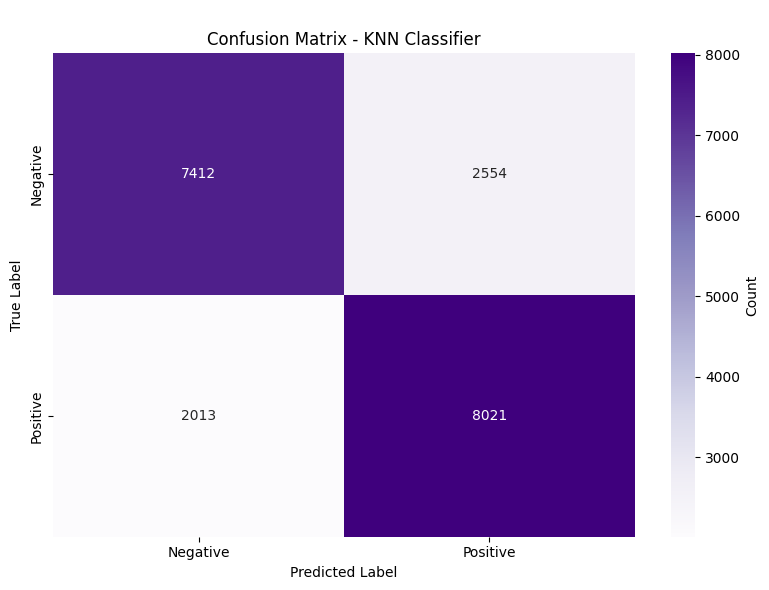

Confusion Matrix:
[[7412 2554]
 [2013 8021]]

True Negatives: 7412
False Positives: 2554
False Negatives: 2013
True Positives: 8021


In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('\nConfusion Matrix - KNN Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('docs/02_results/knn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Hyperparameter Sensitivity: k vs. F1-Score

This plot shows how the number of neighbors `k` affects the cross-validated F1-score for each metric, giving intuition about the optimal neighbourhood size.

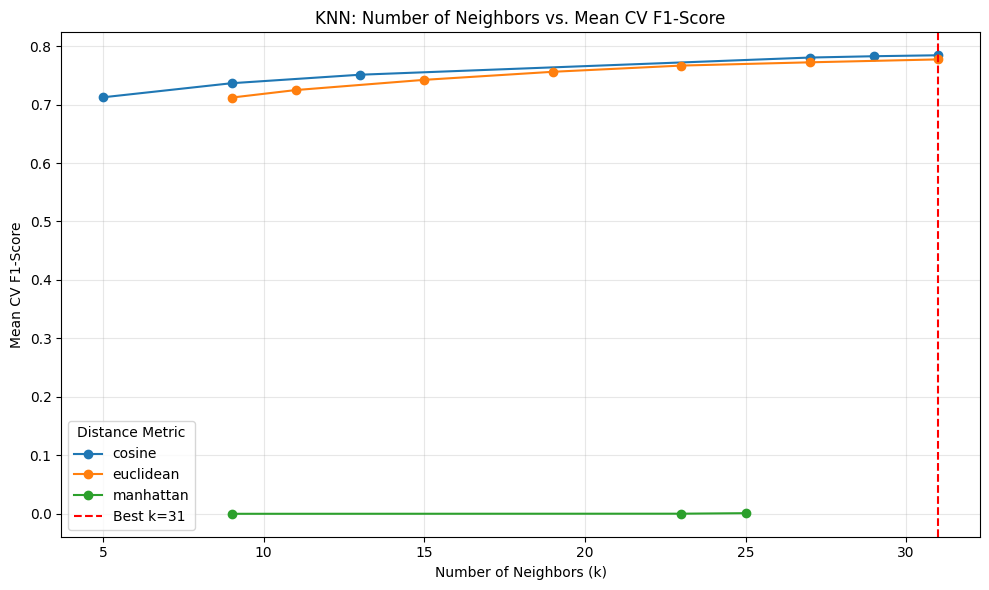

In [ ]:
# Filter CV results to the best metric and plot k vs. mean F1
cv_df = pd.DataFrame(random_search.cv_results_)

# Extract k values and metric from params column
cv_df['n_neighbors'] = cv_df['params'].apply(lambda p: p['n_neighbors'])
cv_df['metric'] = cv_df['params'].apply(lambda p: p['metric'])

plt.figure(figsize=(10, 6))
for metric_name, group in cv_df.groupby('metric'):
    agg = group.groupby('n_neighbors')['mean_test_score'].mean().reset_index()
    plt.plot(agg['n_neighbors'], agg['mean_test_score'], marker='o', label=metric_name)

plt.axvline(x=random_search.best_params_['n_neighbors'], color='red',
            linestyle='--', label=f'Best k={random_search.best_params_["n_neighbors"]}')
plt.title('KNN: Number of Neighbors vs. Mean CV F1-Score')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV F1-Score')
plt.legend(title='Distance Metric')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('docs/02_results/knn_k_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

## Model Summary

In [ ]:
print("KNN MODEL SUMMARY")
print(f"\nBest Hyperparameters (found via RandomizedSearchCV):")
for param, value in random_search.best_params_.items():
    print(f"  - {param}: {value}")
print(f"  - algorithm: brute (required for sparse input & cosine metric)")
print(f"\nHyperparameter Search Details:")
print(f"  - Search Strategy: RandomizedSearchCV")
print(f"  - Iterations: 20")
print(f"  - Cross-Validation Folds: 3")
print(f"  - Scoring Metric: F1")
print(f"  - Best CV F1-Score: {random_search.best_score_:.4f}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {search_time:.4f} seconds")

KNN MODEL SUMMARY

Best Hyperparameters (found via RandomizedSearchCV):
  - weights: uniform
  - p: 2
  - n_neighbors: 31
  - metric: cosine
  - leaf_size: 40
  - algorithm: brute (required for sparse input & cosine metric)

Hyperparameter Search Details:
  - Search Strategy: RandomizedSearchCV
  - Iterations: 20
  - Cross-Validation Folds: 3
  - Scoring Metric: F1
  - Best CV F1-Score: 0.7844

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.7716
  - Precision: 0.7864
  - Recall:    0.7437
  - F1-Score:  0.7645
  - Total Search + Train Time: 414.5409 seconds


## Saving the Model and Pipeline

In [17]:
save(model_base='data/models', model=knn_classifier, model_name='8_knn_classifier.joblib')

Saved model 8_knn_classifier.joblib to data\models\8_knn_classifier.joblib


{'model': WindowsPath('data/models/8_knn_classifier.joblib')}